# Bogus Basin Snow Depth

In [4]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d
from utils import mainutil
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

*Utility functions*


In [5]:
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true- pred) ** 2) / np.sum((true- np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)

def to_ts(data, dates=None):
    data = data.copy()
    aDict = {'ts': np.array(data)}
    aRange = np.arange(len(data))
    aDict['pts'] = (aRange - np.min(aRange)) / np.max(aRange)
    if dates is not None:
        indexDates = pd.to_datetime(dates, errors='coerce')
    elif isinstance(data, pd.Series) and isinstance(data.index, pd.DatetimeIndex):
        indexDates = data.index
    else:
        indexDates = aRange
    return pd.DataFrame(aDict, index=indexDates).dropna()

## Plot and Exploratory Analysis

*Read data*

In [6]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])

snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_daily = to_ts(snow_data['Depth'], snow_data.index)


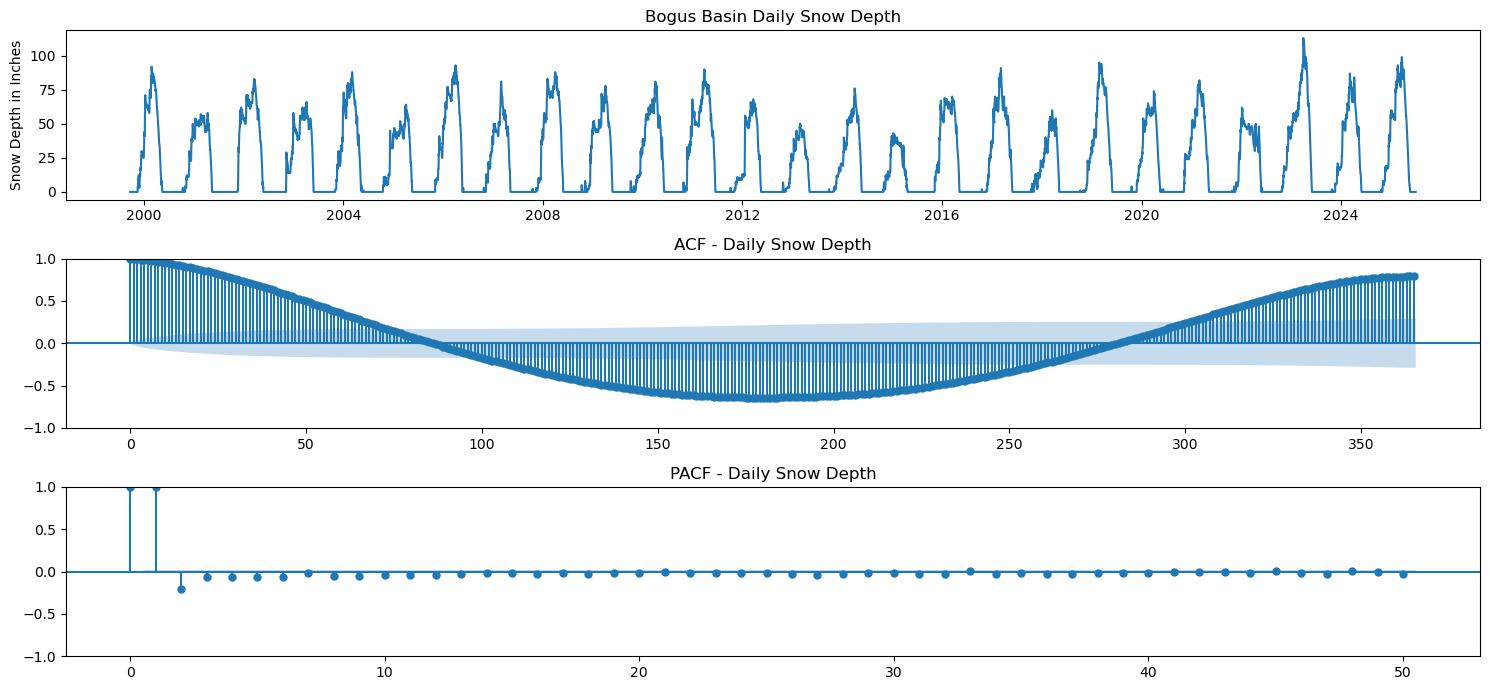

In [7]:
fig, axs = plt.subplots(3,1 ,figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")
plot_acf(snow_daily['ts'], lags = 365, ax = axs[1], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[2], title = "PACF - Daily Snow Depth");

# axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
# axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
# axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

The daily snow data exhibits a strong seasonal pattern with no clear discernable trend. A key feature of this data is the large periods of time with zero values during the warmer months.  While one approach could be to remove all the zero values, they are a key data point, as forecasting when snow begins and ends is a key part of this analysis.  Close attention will be paid to how successful the models are in capturing these zero points. 

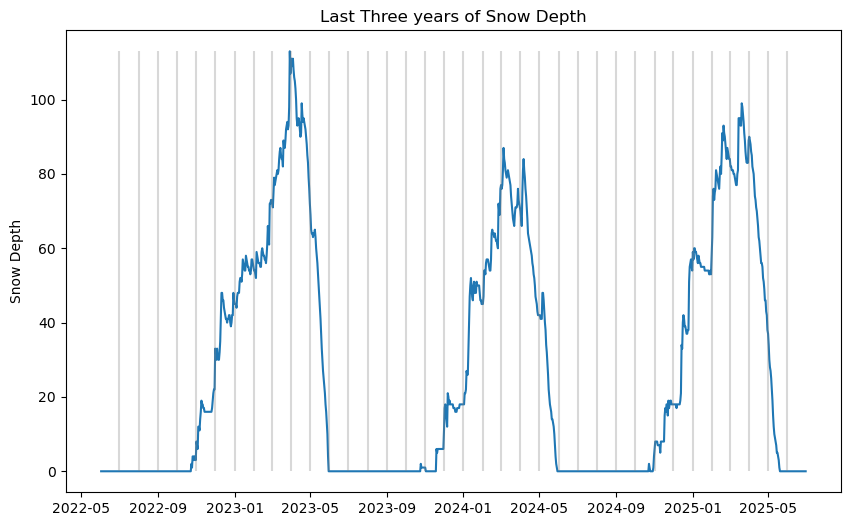

In [8]:
last_3_years = snow_daily[snow_daily.index > '2022-06-01']
loc = mdates.MonthLocator(bymonthday=1)
month_starts = loc.tick_values(last_3_years.index.min(), last_3_years.index.max())

plt.figure(figsize=(10,6))
plt.plot(last_3_years['ts'])
plt.vlines(month_starts, 0,last_3_years['ts'].max(), alpha = .3, color = 'grey')
plt.title("Last Three years of Snow Depth")
plt.ylabel("Snow Depth")
plt.show()


Focusing in on the last three years of snow data shows interesting patterns in each year.  The warmer months have a snow depth of 0, typically from June to October or November.  Snow depth is dictated by snow storms, which lead to a sharp increase in snow depth.  The sharp increase is followed by a period of no increase or slight decrease, as snow melts. The peak of snow depth is reached around April each year, when warming temperatures lead melting snow and a sharp decrease in snow levels.  

## Modeling



Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical viariables at month, week, and day levels for seasonal analysis 

In [9]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['ts'] = sd['ts']+1
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())


            ts       pts  month  week  day
Date                                      
2024-05-27   5  0.957598      5    22  148
2024-05-28   3  0.957705      5    22  149
2024-05-29   2  0.957811      5    22  150
2024-05-30   1  0.957917      5    22  151
2024-05-31   1  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   1  0.958130      6    22  153
2024-06-02   1  0.958236      6    22  154
2024-06-03   1  0.958342      6    23  155
2024-06-04   1  0.958448      6    23  156
2024-06-05   1  0.958555      6    23  157


### Trend Estimation Using Moving Average, Local Polynomial, and Splines

In [10]:
#Moving Average Trend
mavModel = uniform_filter1d(sd_train['ts'], size=len(sd_train['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=sd_train.index)


#Lowess Trend
localPolyModel = sm.nonparametric.lowess(endog=sd_train['ts'], exog=sd_train['pts'], is_sorted=True, frac=0.5)

## extrapolate local polynomial and Moving Average onto test data
f = interp1d(localPolyModel[:,0], localPolyModel[:,1], bounds_error=False, fill_value="extrapolate")
sd_test['LocalPoly_Trend'] = f(sd_test['pts'])
sd_test['MovingAvg_Trend'] = mav_data[-1]

# Splines Trend
gamModel = GLMGam.from_formula(
    formula='ts ~ 1', data=sd_train, alpha=100,
    family=sm.families.Gaussian(),
    smoother=BSplines(sd_train['pts'], df=30, degree=3)).fit()



localPolyData = pd.Series(localPolyModel[:,1], index=sd_train.index)
sd_train['MovingAvg_Trend'] = mav_data
sd_train['LocalPoly_Trend'] = localPolyData
sd_train['spline'] = gamModel.fittedvalues


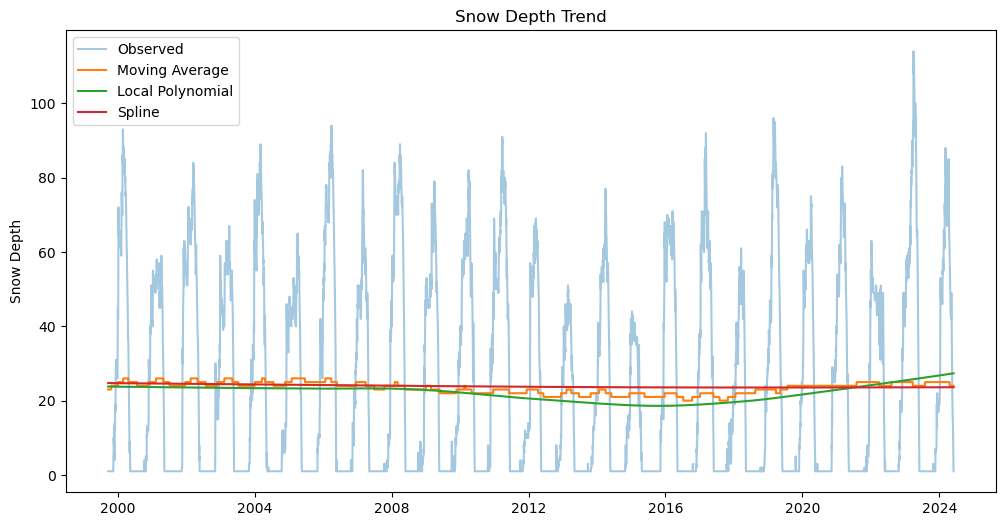

In [11]:
plt.figure(figsize = (12,6))
plt.plot(sd_train['ts'], alpha =.4)
plt.plot(sd_train['MovingAvg_Trend'])

plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['spline'])

plt.legend(['Observed', 'Moving Average', 'Local Polynomial', 'Spline'])
plt.ylabel('Snow Depth')
plt.title("Snow Depth Trend")
plt.show()

To determine any trend in the data, a moving average, local polynomial using LOWESS, and splines regression were all used.  The moving average appears to capture some of the seasonal pattern in the data.  The splines regression shows no discernable trend, while the local polynomial shows a slight decrease from 2012 to 2016, and then an increase from 2016 till 2024. As the local polynomial appears to best capture the long term fluctuations in the daily snow levels, it will be used in further decomposition models. 

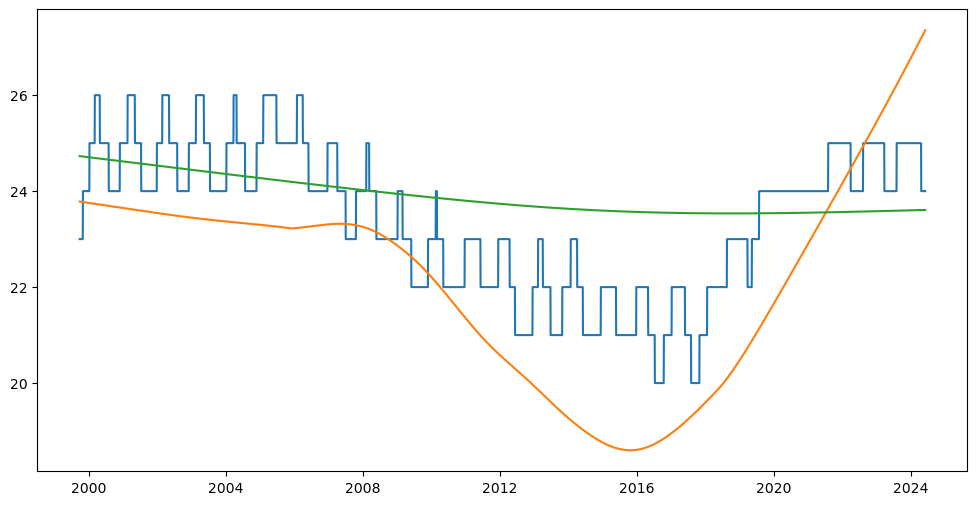

In [12]:
plt.figure(figsize = (12,6))

plt.plot(sd_train['MovingAvg_Trend'])
plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['spline'])

### Seaonality Estimation

In [13]:
def generate_fourier_terms(time, period, K):

    fourier_terms = {}
    for k in range(1, K + 1):
        fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time / period)
        fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time / period)
    return pd.DataFrame(fourier_terms)


f_train = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)
f_train =f_train.set_index(sd_train.index)
f_train


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


In [14]:
sd_train =sd_train.join(f_train)


In [15]:


sd_train['ts_sqrt'] = np.sqrt(sd_train['ts'])


seasonalmodel_LocalPoly_trend_Harmonic2 = smf.ols(formula = 'ts~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
seasonal_model_WeeklyAnova_w_Poly = smf.ols(formula = 'ts~C(week)+LocalPoly_Trend', data = sd_train).fit()
seasonal_model_MonthlyAnova_w_Poly = smf.ols(formula = 'ts~C(month)+MovingAvg_Trend', data = sd_train).fit()
seasonal_monthlyANOVA_Harmonics3 = smf.ols(formula = 'ts~C(month)+LocalPoly_Trend + sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()


In [17]:
spline = BSplines(sd_train['pts'], degree=3, df=50)
harmonic_3_gam = GLMGam(endog= sd_train['ts'], exog=f_train, smoother=spline).fit()

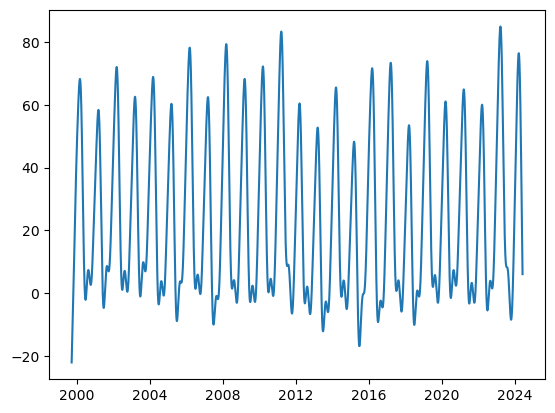

In [19]:
plt.plot(harmonic_3_gam.fittedvalues)

In [271]:
def analysis_plots(observed, fitted, residuals,  model_name):
    fig, axs = plt.subplots(4,1, figsize =(12,14) )
    axs[0].plot(observed, color = 'grey', alpha = .7)
    axs[0].plot(fitted, color = 'green')
    axs[0].set_ylabel("Snow Depth")
    axs[0].legend(['Observed', model_name], fontsize = 8)
    axs[0].set_title(model_name, size=10)

    axs[1].plot(residuals)
    axs[1].set_ylabel("Residuals")
    axs[1].set_title(f"{model_name} residuals", size = 10)

    plot_acf(residuals, ax=axs[2] )
    plot_pacf(residuals, ax=axs[3] )
    axs[2].set_title(f"ACF: { model_name}", size = 9)
    axs[3].set_title(f"PACF: { model_name}", size = 9)
    df_test = adfuller(residuals, regression = 'c')
    print(f"ADF: Test statistic = {df_test[0]:.4f}, p-value = {df_test[1]:.4f}")
    

ADF: Test statistic = -10.5859, p-value = 0.0000


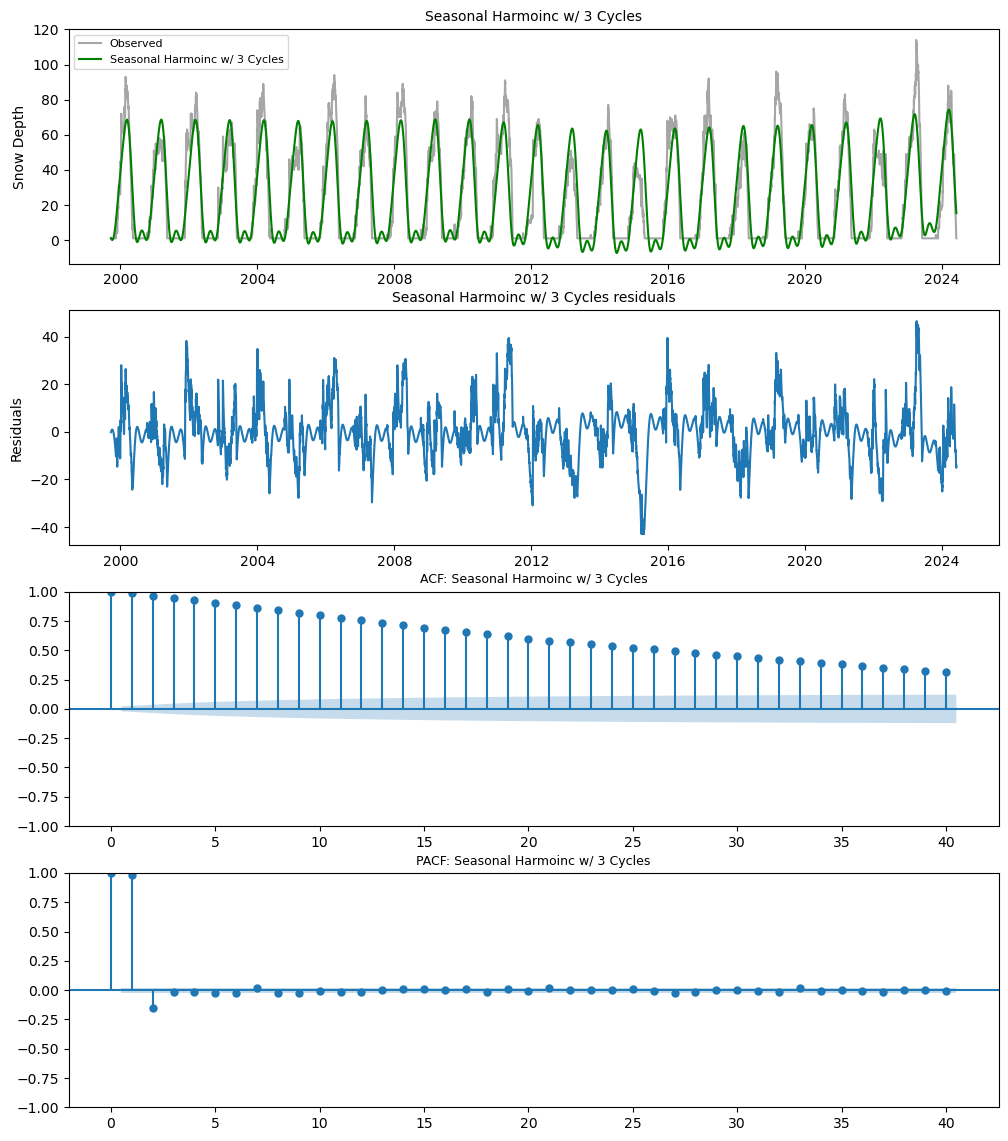

In [272]:
analysis_plots(sd_train['ts'], seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues, seasonalmodel_LocalPoly_trend_Harmonic3.resid, "Seasonal Harmoinc w/ 3 Cycles")

ADF: Test statistic = -10.7403, p-value = 0.0000


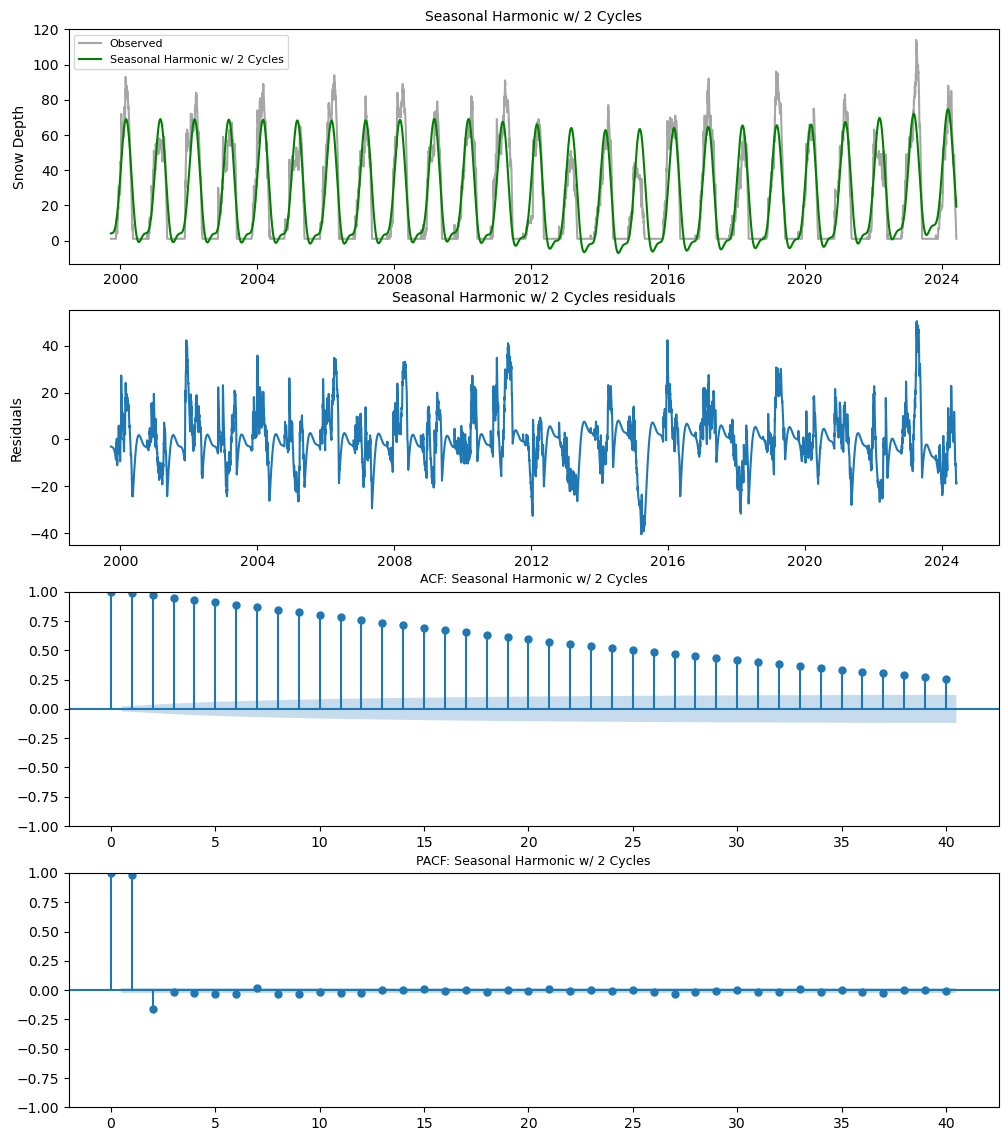

In [273]:
analysis_plots(sd_train['ts'], seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues, seasonalmodel_LocalPoly_trend_Harmonic2.resid, "Seasonal Harmonic w/ 2 Cycles")


ADF: Test statistic = -9.2099, p-value = 0.0000
0.05435588306687109 0.1


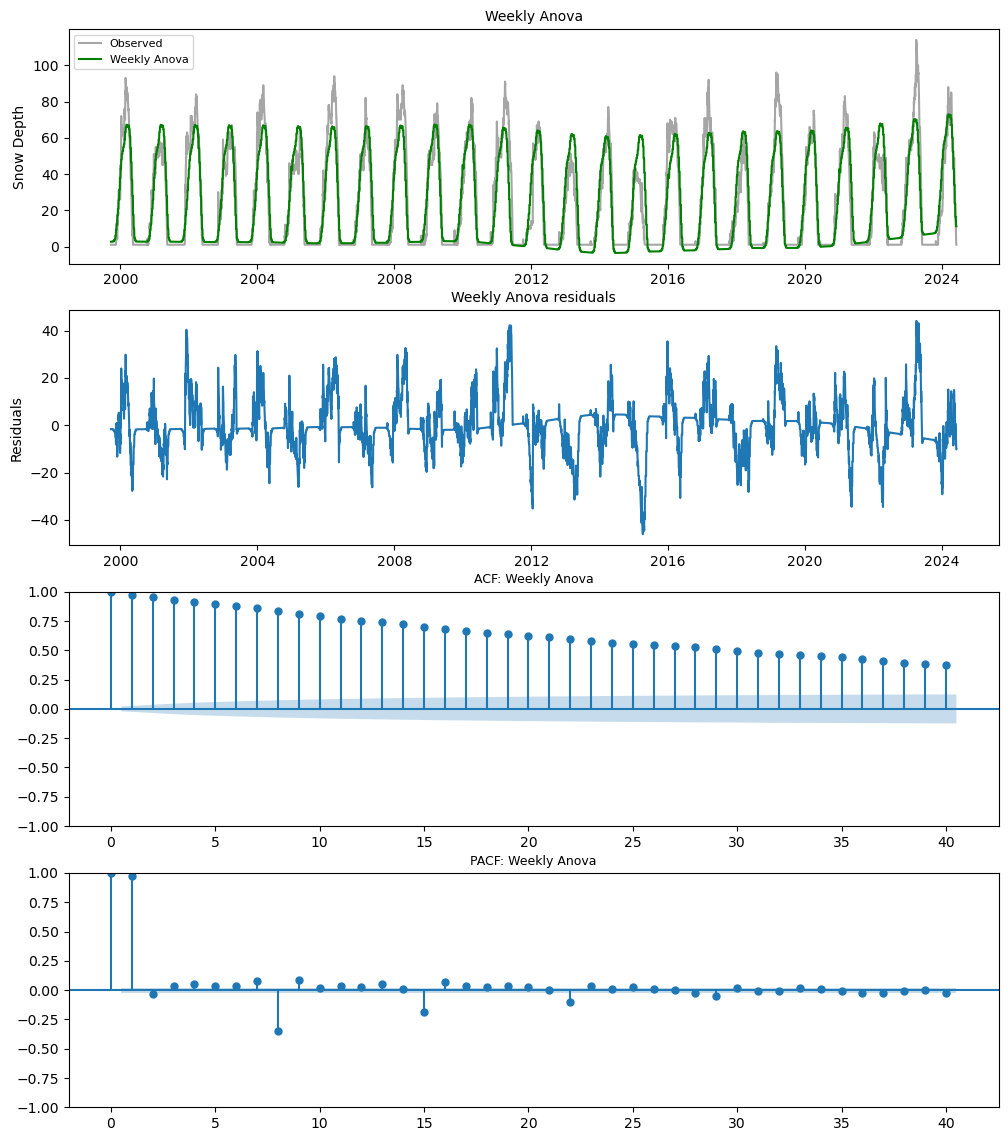

In [274]:
analysis_plots(sd_train['ts'], seasonal_model_WeeklyAnova_w_Poly.fittedvalues, seasonal_model_WeeklyAnova_w_Poly.resid, "Weekly Anova")
statistic, p_value, n_lags, critical_values = kpss(seasonal_model_WeeklyAnova_w_Poly.resid, regression='c')
print(statistic, p_value)

Prepping test data for forecasting

In [275]:
f_test = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
f_test = f_test.set_index(sd_test.index)
sd_test = sd_test.join(f_test)

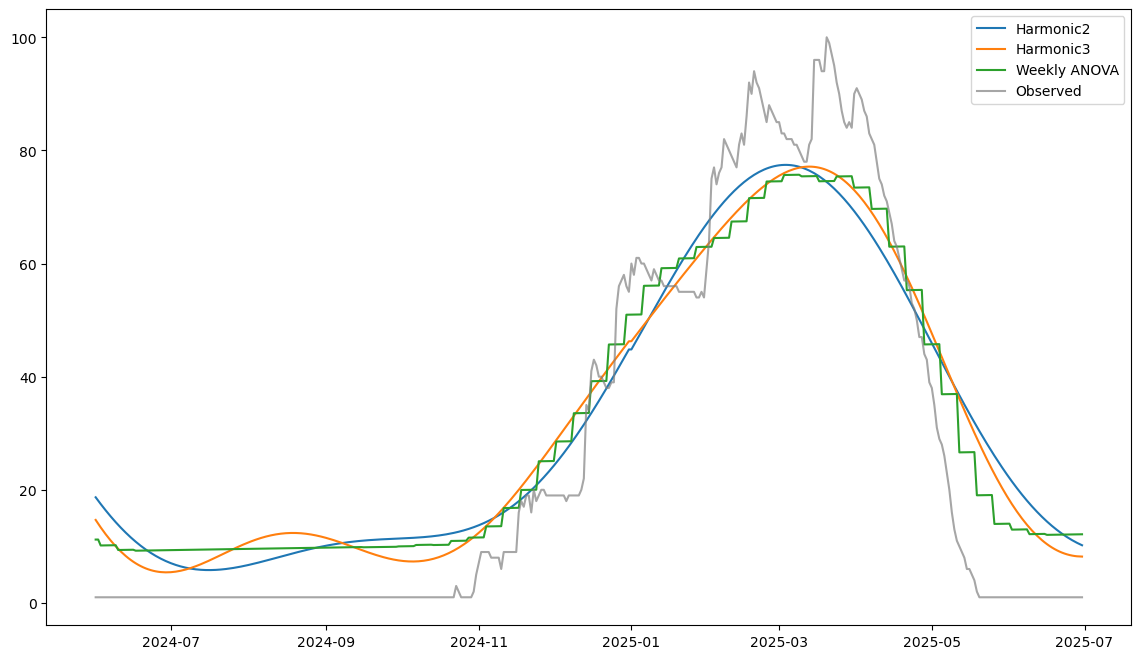

In [276]:

sd_test['ts_sqrt'] = np.sqrt(sd_test['ts'])
sd_test['ts_log'] = np.log(sd_test['ts']+1)
sd_test['mav2'] = sd_test['ts'].rolling(window =180, center = True, min_periods=1).mean()


plt.figure( figsize = (14,8))
#plt.plot(seasonalmodel_LocalPoly_trend_myf.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test))
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test))
#plt.plot(seasonalmodel_no_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_LocalPoly_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_MA_trend.predict(exog=sd_test)**2)
plt.plot(seasonal_model_WeeklyAnova_w_Poly.predict(exog=sd_test))
# plt.plot(seasonal_model_DailyAnova_w_Poly.predict(exog=sd_test)**2)
plt.plot(sd_test['ts'], color = 'grey', alpha = .7)
plt.legend(['Harmonic2', 'Harmonic3', "Weekly ANOVA", 'Observed'])

In [277]:
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test), 'local poly harmonic 2' )
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test), 'local poly harmonic 3' )
evaluate_performance(sd_test['ts'],seasonal_model_WeeklyAnova_w_Poly.predict(exog = sd_test), 'weekly anova' )

=== local poly harmonic 2 Performance ===
MSPE: 142.3998
MAE:  10.1731
MAPE: 5.4481
PM:   0.1300
----------------------------------------
=== local poly harmonic 3 Performance ===
MSPE: 123.5425
MAE:  9.6131
MAPE: 4.8265
PM:   0.1128
----------------------------------------
=== weekly anova Performance ===
MSPE: 109.0463
MAE:  9.3386
MAPE: 4.8846
PM:   0.0996
----------------------------------------


In [278]:
maxp=7
maxd=2
maxq=7

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = f_train,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(0, 1, 7) 36356.39879312356


In [279]:
arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
print(arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                     ts   No. Observations:                 9016
Model:               SARIMAX(0, 1, 7)   Log Likelihood              -18086.640
Date:                Sun, 26 Apr 2026   AIC                          36201.280
Time:                        16:58:36   BIC                          36300.773
Sample:                             0   HQIC                         36235.132
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         27.9409      3.756      7.438      0.000      20.579      35.303
cos_1         17.8729      3.624      4.932      0.000      10.770      24.975
sin_2          8.4882      2.562      3.313      0.0

ADF: Test statistic = -95.9361, p-value = 0.0000


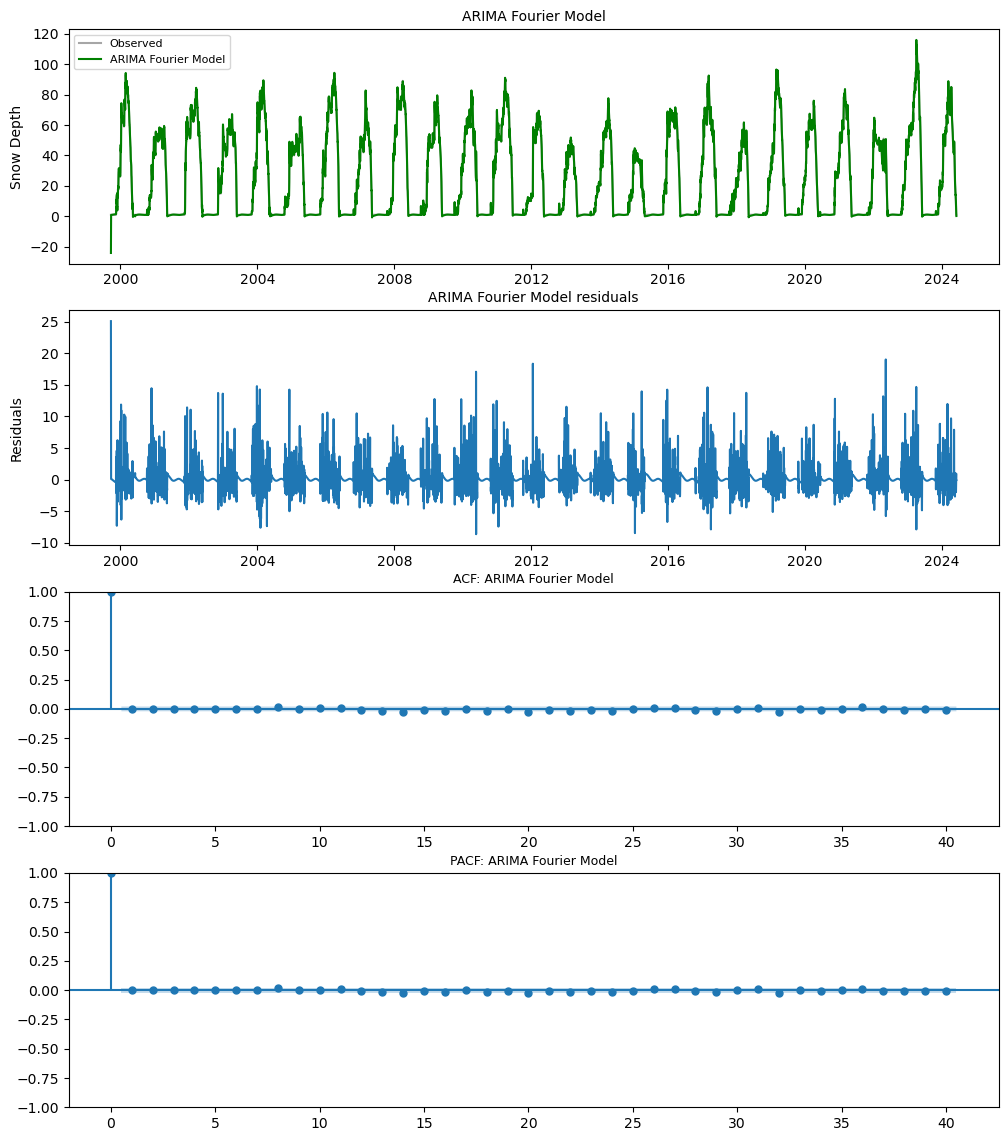

In [280]:
analysis_plots(sd_train['ts'],arima_fourier_model.fittedvalues, arima_fourier_model.resid, "ARIMA Fourier Model" )



In [281]:
statistic, p_value, n_lags, critical_values = kpss(arima_fourier_model.resid, regression='c')
print(statistic, p_value)

0.01103962747386482 0.1


In [284]:
arima_yr_forecast = arima_fourier_model.forecast(steps = 395, exog = f_test)

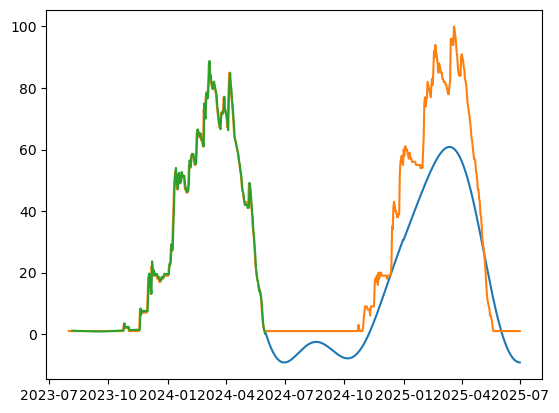

In [285]:
plt.plot(sd_test.index, arima_yr_forecast )
plt.plot(sd['ts'][-700:])
plt.plot(arima_fourier_model.fittedvalues[-300:])


In [287]:
evaluate_performance(sd_test['ts'], arima_yr_forecast, 'Arima' )

=== Arima Performance ===
MSPE: 241.6945
MAE:  12.4041
MAPE: nan
PM:   0.0000
----------------------------------------


In [288]:
arima_yr_forecast = mainutil.to_ts(arima_yr_forecast,sd_test.index)

In [289]:

evaluate_performance(sd_test['ts'], arima_yr_forecast['ts'])

=== Model Performance ===
MSPE: 241.6945
MAE:  12.4041
MAPE: 3.4599
PM:   0.2207
----------------------------------------


In [290]:
sd_train_roll = sd_train.copy()


In [ ]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    results.append(forecast)
full_forecast = pd.concat(results)




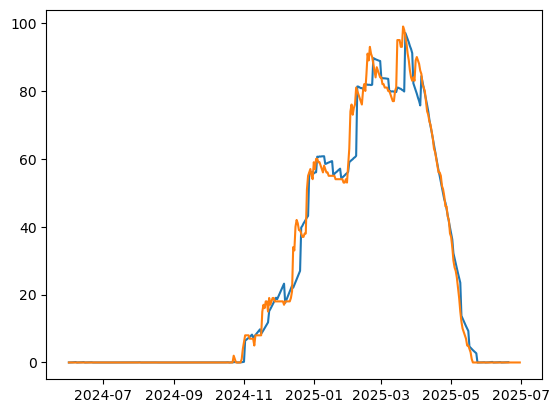

In [62]:
plt.plot(full_forecast**2)
plt.plot(sd_test['ts'])


In [64]:
evaluate_performance(sd_test['ts'][:385], full_forecast**2, "arima 7 day rolling")

=== arima 7 day rolling Performance ===
MSPE: 18.6876
MAE:  2.1546
MAPE: 41246.8821
PM:   0.0169
----------------------------------------


## Facebook Prophet

In [168]:
prof_train = pd.DataFrame( sd_train.index, sd_train.copy()['ts']).reset_index()

prof_train.rename(columns={'ts':'y', 'Date':'ds'}, inplace=True)
prof_train.head()

prof_test = pd.DataFrame( sd_test.index, sd_test.copy()['ts']).reset_index()

prof_test.rename(columns={'ts':'y', 'Date':'ds'}, inplace=True)
prof_test.head()

,y,ds
0,1,2024-06-01
1,1,2024-06-02
2,1,2024-06-03
3,1,2024-06-04
4,1,2024-06-05


19:11:21 - cmdstanpy - INFO - Chain [1] start processing
19:11:23 - cmdstanpy - INFO - Chain [1] done processing


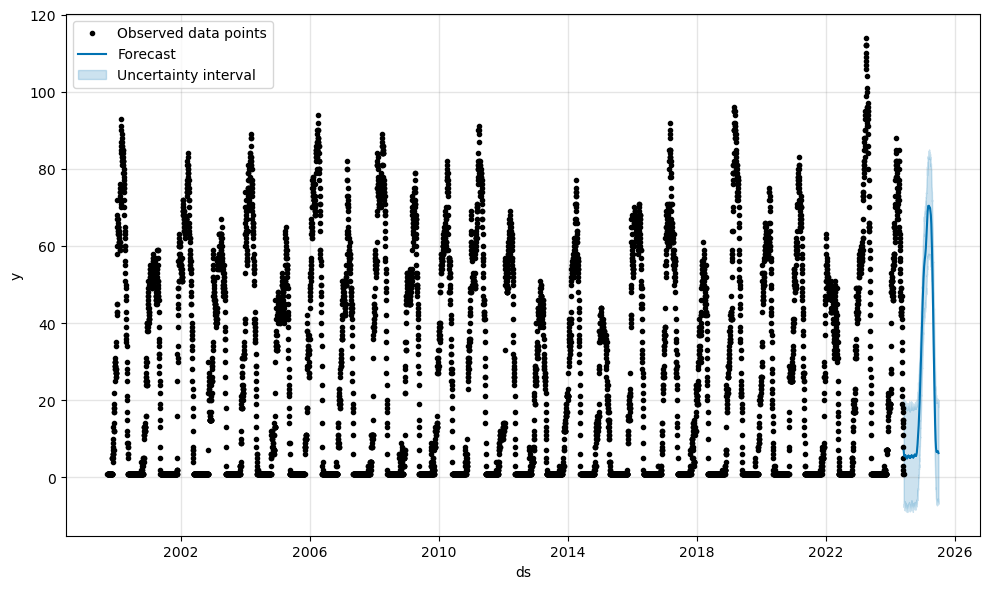

In [346]:
m = Prophet()
m.fit(prof_train)
prof_forecast = m.predict(prof_test)
plot = m.plot(prof_forecast, include_legend=True, )
plot.show()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-06-01,27.718710,-5.930921,20.727022,27.718710,27.718710,-20.774031,-20.774031,-20.774031,-0.019619,-0.019619,-0.019619,-20.754411,-20.754411,-20.754411,0.0,0.0,0.0,6.944679
1,2024-06-02,27.721633,-6.290572,20.395421,27.721633,27.721633,-21.112313,-21.112313,-21.112313,-0.011037,-0.011037,-0.011037,-21.101276,-21.101276,-21.101276,0.0,0.0,0.0,6.609319
2,2024-06-03,27.724555,-7.707470,18.739735,27.724555,27.724555,-21.430004,-21.430004,-21.430004,-0.037324,-0.037324,-0.037324,-21.392680,-21.392680,-21.392680,0.0,0.0,0.0,6.294551
3,2024-06-04,27.727478,-6.735012,19.269814,27.727478,27.727478,-21.632328,-21.632328,-21.632328,-0.000155,-0.000155,-0.000155,-21.632172,-21.632172,-21.632172,0.0,0.0,0.0,6.095150
4,2024-06-05,27.730400,-7.669497,18.548904,27.730400,27.730400,-21.794691,-21.794691,-21.794691,0.029041,0.029041,0.029041,-21.823732,-21.823732,-21.823732,0.0,0.0,0.0,5.935710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,2025-06-26,28.858529,-6.137870,19.658651,28.272585,29.421666,-22.180618,-22.180618,-22.180618,0.069873,0.069873,0.069873,-22.250492,-22.250492,-22.250492,0.0,0.0,0.0,6.677911
391,2025-06-27,28.861452,-6.452940,18.327955,28.268871,29.426523,-22.345337,-22.345337,-22.345337,-0.030779,-0.030779,-0.030779,-22.314557,-22.314557,-22.314557,0.0,0.0,0.0,6.516115
392,2025-06-28,28.864375,-6.361838,19.036406,28.266474,29.429594,-22.402824,-22.402824,-22.402824,-0.019619,-0.019619,-0.019619,-22.383204,-22.383204,-22.383204,0.0,0.0,0.0,6.461551
393,2025-06-29,28.867297,-6.831630,20.065901,28.272392,29.432666,-22.465470,-22.465470,-22.465470,-0.011037,-0.011037,-0.011037,-22.454433,-22.454433,-22.454433,0.0,0.0,0.0,6.401828


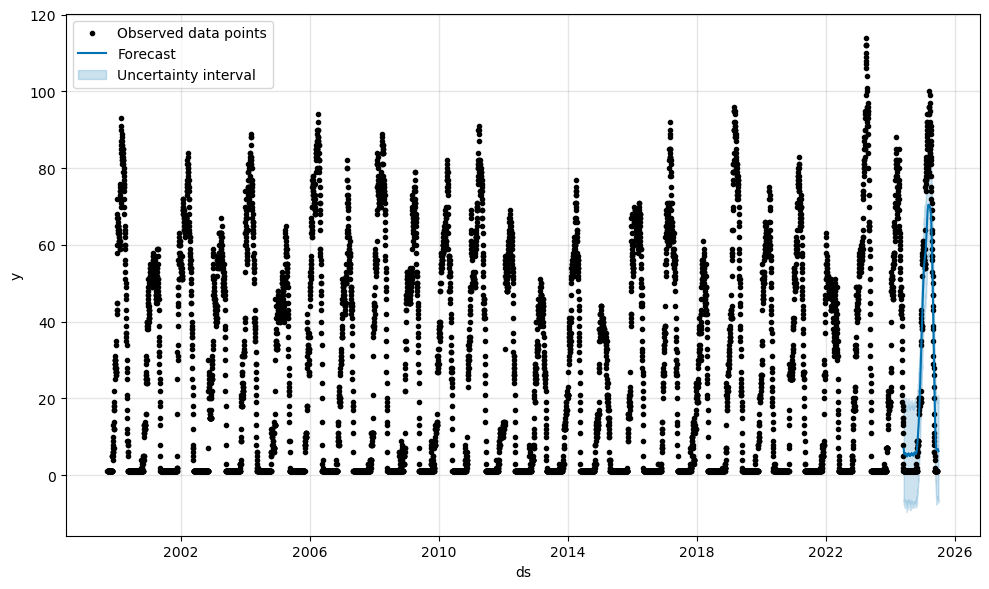

In [344]:
plot=m.plot(prof_forecast, include_legend=True, )

plot.show()

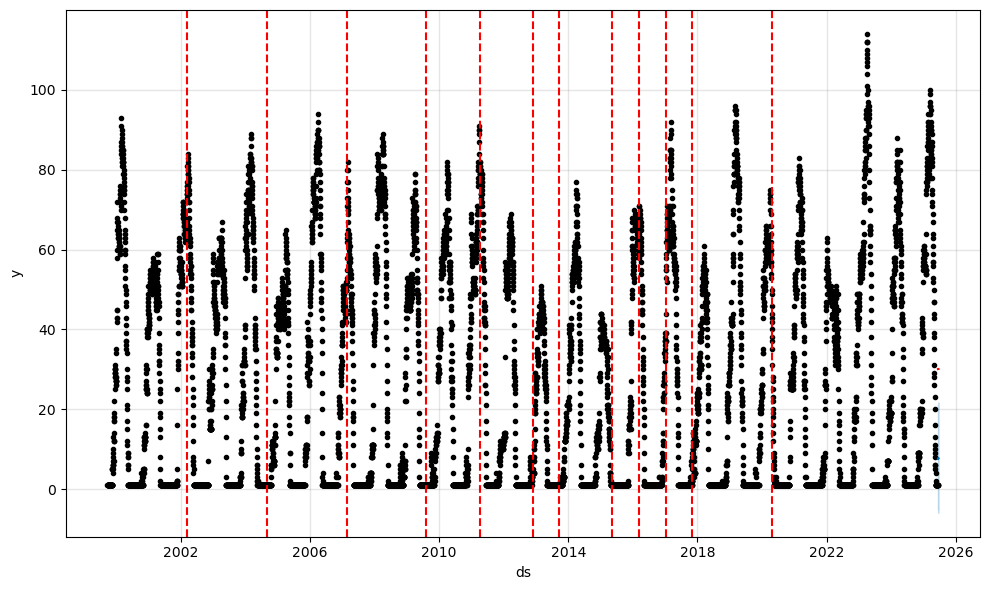

In [341]:
from prophet.plot import add_changepoints_to_plot
fig = m.plot(forecast[-300:])
a = add_changepoints_to_plot(fig.gca(),
                             m, forecast[-300:])

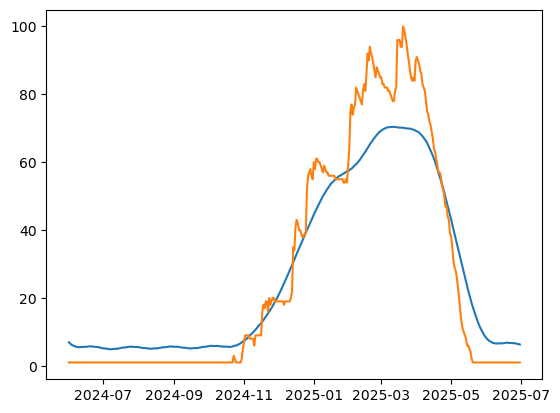

In [171]:
plt.plot(sd_test.index, prof_forecast['yhat'])
plt.plot(sd_test['ts'])

In [172]:
evaluate_performance(sd_test['ts'], prof_forecast['yhat'], 'profet')

=== profet Performance ===
MSPE: 97.4432
MAE:  7.6013
MAPE: nan
PM:   0.0000
----------------------------------------


In [176]:
prof_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-06-01,27.718710,-6.300760,19.956956,27.718710,27.718710,-20.774031,-20.774031,-20.774031,-0.019619,-0.019619,-0.019619,-20.754411,-20.754411,-20.754411,0.0,0.0,0.0,6.944679
1,2024-06-02,27.721633,-6.674102,20.436245,27.721633,27.721633,-21.112313,-21.112313,-21.112313,-0.011037,-0.011037,-0.011037,-21.101276,-21.101276,-21.101276,0.0,0.0,0.0,6.609319
2,2024-06-03,27.724555,-6.263081,19.273055,27.724555,27.724555,-21.430004,-21.430004,-21.430004,-0.037324,-0.037324,-0.037324,-21.392680,-21.392680,-21.392680,0.0,0.0,0.0,6.294551
3,2024-06-04,27.727478,-7.670626,18.651204,27.727478,27.727478,-21.632328,-21.632328,-21.632328,-0.000155,-0.000155,-0.000155,-21.632172,-21.632172,-21.632172,0.0,0.0,0.0,6.095150
4,2024-06-05,27.730400,-7.259070,18.930421,27.730400,27.730400,-21.794691,-21.794691,-21.794691,0.029041,0.029041,0.029041,-21.823732,-21.823732,-21.823732,0.0,0.0,0.0,5.935710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,2025-06-26,28.858529,-6.918677,19.883882,28.218559,29.445615,-22.180618,-22.180618,-22.180618,0.069873,0.069873,0.069873,-22.250492,-22.250492,-22.250492,0.0,0.0,0.0,6.677911
391,2025-06-27,28.861452,-7.037042,18.880337,28.218681,29.450378,-22.345337,-22.345337,-22.345337,-0.030779,-0.030779,-0.030779,-22.314557,-22.314557,-22.314557,0.0,0.0,0.0,6.516115
392,2025-06-28,28.864375,-6.437982,19.427311,28.218802,29.453231,-22.402824,-22.402824,-22.402824,-0.019619,-0.019619,-0.019619,-22.383204,-22.383204,-22.383204,0.0,0.0,0.0,6.461551
393,2025-06-29,28.867297,-6.779705,19.029747,28.218924,29.459054,-22.465470,-22.465470,-22.465470,-0.011037,-0.011037,-0.011037,-22.454433,-22.454433,-22.454433,0.0,0.0,0.0,6.401828


In [174]:
yhat = mainutil.to_ts(prof_forecast['yhat'], prof_test['ds'])

yhat

,ts,pts
ds,,
2024-06-01,6.944679,0.000000
2024-06-02,6.609319,0.002538
2024-06-03,6.294551,0.005076
2024-06-04,6.095150,0.007614
2024-06-05,5.935710,0.010152
...,...,...
2025-06-26,6.677911,0.989848
2025-06-27,6.516115,0.992386
2025-06-28,6.461551,0.994924


In [175]:
evaluate_performance(sd_test['ts'], yhat['ts'], 'prof')

=== prof Performance ===
MSPE: 97.4432
MAE:  7.6013
MAPE: 2.6645
PM:   0.0890
----------------------------------------


In [297]:

prof_test

,y,ds
0,1,2024-06-01
1,1,2024-06-02
2,1,2024-06-03
3,1,2024-06-04
4,1,2024-06-05
...,...,...
390,1,2025-06-26
391,1,2025-06-27
392,1,2025-06-28
393,1,2025-06-29


In [326]:
fb_train_rolling = prof_train.copy()
fb_test_rolling = prof_test.copy()

forecast_period = 7
number_of_runs = len(fb_test_rolling)//forecast_period
results = []
for r in range(1,number_of_runs):
    if r == 1:
        fb_train_rolling = prof_train.copy()
        fb_test_rolling = prof_test.copy()[:forecast_period]
    else: 
        fb_train_rolling = pd.concat([fb_train_rolling, fb_test_rolling])
        fb_test_rolling = prof_test.copy()[forecast_period*(r-1):forecast_period*r]
   
    
    if len(fb_test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(fb_test_rolling)
    m = Prophet()
    model = m.fit(fb_train_rolling)
    forecast = m.predict(fb_test_rolling)
    
    #forecast = forecast.set_axis(test_rolling.index)
     
    results.append(forecast)
full_forecast = pd.concat(results)

18:57:37 - cmdstanpy - INFO - Chain [1] start processing
18:57:38 - cmdstanpy - INFO - Chain [1] done processing
18:57:38 - cmdstanpy - INFO - Chain [1] start processing
18:57:39 - cmdstanpy - INFO - Chain [1] done processing
18:57:40 - cmdstanpy - INFO - Chain [1] start processing
18:57:40 - cmdstanpy - INFO - Chain [1] done processing
18:57:41 - cmdstanpy - INFO - Chain [1] start processing
18:57:42 - cmdstanpy - INFO - Chain [1] done processing
18:57:42 - cmdstanpy - INFO - Chain [1] start processing
18:57:43 - cmdstanpy - INFO - Chain [1] done processing
18:57:43 - cmdstanpy - INFO - Chain [1] start processing
18:57:45 - cmdstanpy - INFO - Chain [1] done processing
18:57:45 - cmdstanpy - INFO - Chain [1] start processing
18:57:46 - cmdstanpy - INFO - Chain [1] done processing
18:57:46 - cmdstanpy - INFO - Chain [1] start processing
18:57:48 - cmdstanpy - INFO - Chain [1] done processing
18:57:48 - cmdstanpy - INFO - Chain [1] start processing
18:57:49 - cmdstanpy - INFO - Chain [1]

In [327]:
full_forecast.set_index(full_forecast['ds'], drop=True, inplace=True)

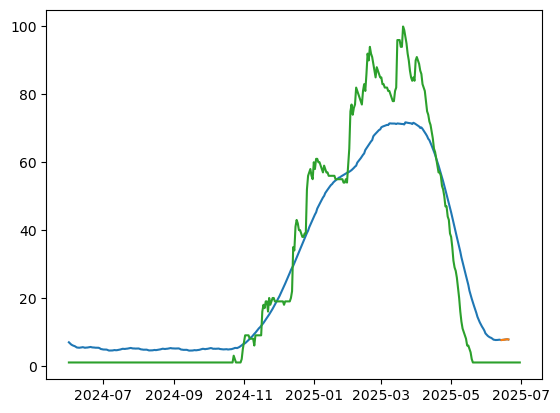

In [335]:
plt.plot(full_forecast['yhat'])
plt.plot( forecast['ds'], forecast['yhat'])
plt.plot(sd_test['ts'])

In [332]:
evaluate_performance(sd_test['ts'][0:385], full_forecast['yhat'], 'Profet 7 day rolling')

=== Profet 7 day rolling Performance ===
MSPE: 96.7529
MAE:  7.5156
MAPE: 2.5021
PM:   0.0875
----------------------------------------
